# D — Cooling Effect: ΔT Between Areas
Quantifies how much cooler the Shaded area (vegetation/shade) and Waterfront area
are compared to the dense urban canyon (Zefkseidos) at each hour and season.

ΔT = T(Zefkseidos) − T(other area)  →  positive = other area is cooler.

**Saves to** `../figures/D_cooling_effect/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *
import matplotlib.patches as mpatches

SAVE_DIR = FIGURES_DIR / 'D_cooling_effect'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_AREA = 'Zefkseidos'   # dense canyon — used as baseline
print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/D_cooling_effect


In [2]:
print('Loading atmosphere...'); atm_raw = load_csvs('atmosphere')
print('Loading surface...');    srf_raw = load_csvs('surface')
SURF_TEMP_COL, _ = detect_surface_cols(srf_raw)
atm = atm_raw[atm_raw[BUILDING_COL] == 0].copy() if BUILDING_COL in atm_raw.columns else atm_raw.copy()
srf = srf_raw.copy()
print('Loaded.')

Loading atmosphere...
  Shaded_15Aug_atmosphere.parquet  →  260,000 rows
  Shaded_15Feb_atmosphere.parquet  →  260,000 rows
  Shaded_15Nov_atmosphere.parquet  →  510,000 rows
  Shaded_31Mar_atmosphere.parquet  →  260,000 rows
  Waterfront_15Aug_atmosphere.parquet  →  260,000 rows
  Waterfront_15Feb_atmosphere.parquet  →  260,000 rows
  Waterfront_15Nov_atmosphere.parquet  →  260,000 rows
  Waterfront_31Mar_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Aug_atmosphere.parquet  →  300,000 rows
  Zefkseidos_15Feb_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Nov_atmosphere.parquet  →  260,000 rows
  Zefkseidos_31Mar_atmosphere.parquet  →  260,000 rows
Loading surface...
  Shaded_15Aug_surface.parquet  →  250,000 rows
  Shaded_15Feb_surface.parquet  →  250,000 rows
  Shaded_15Nov_surface.parquet  →  250,000 rows
  Shaded_31Mar_surface.parquet  →  250,000 rows
  Waterfront_15Aug_surface.parquet  →  250,000 rows
  Waterfront_15Feb_surface.parquet  →  250,000 rows
  Waterfront_15Nov_

## Helper — build hourly mean table and compute ΔT

In [3]:
def hourly_means(df, col):
    """Return pivot: index=hour, columns=(area, date), values=mean temperature."""
    grp = df.groupby(['area', 'date', 'hour'])[col].mean().reset_index()
    return grp.pivot_table(index='hour', columns=['area', 'date'], values=col)

atm_piv = hourly_means(atm, AIR_TEMP_COL)
srf_piv = hourly_means(srf, SURF_TEMP_COL)
print('Hourly mean tables built.')

Hourly mean tables built.


## D1 — ΔT air temperature diurnal curves (vs Zefkseidos) per season

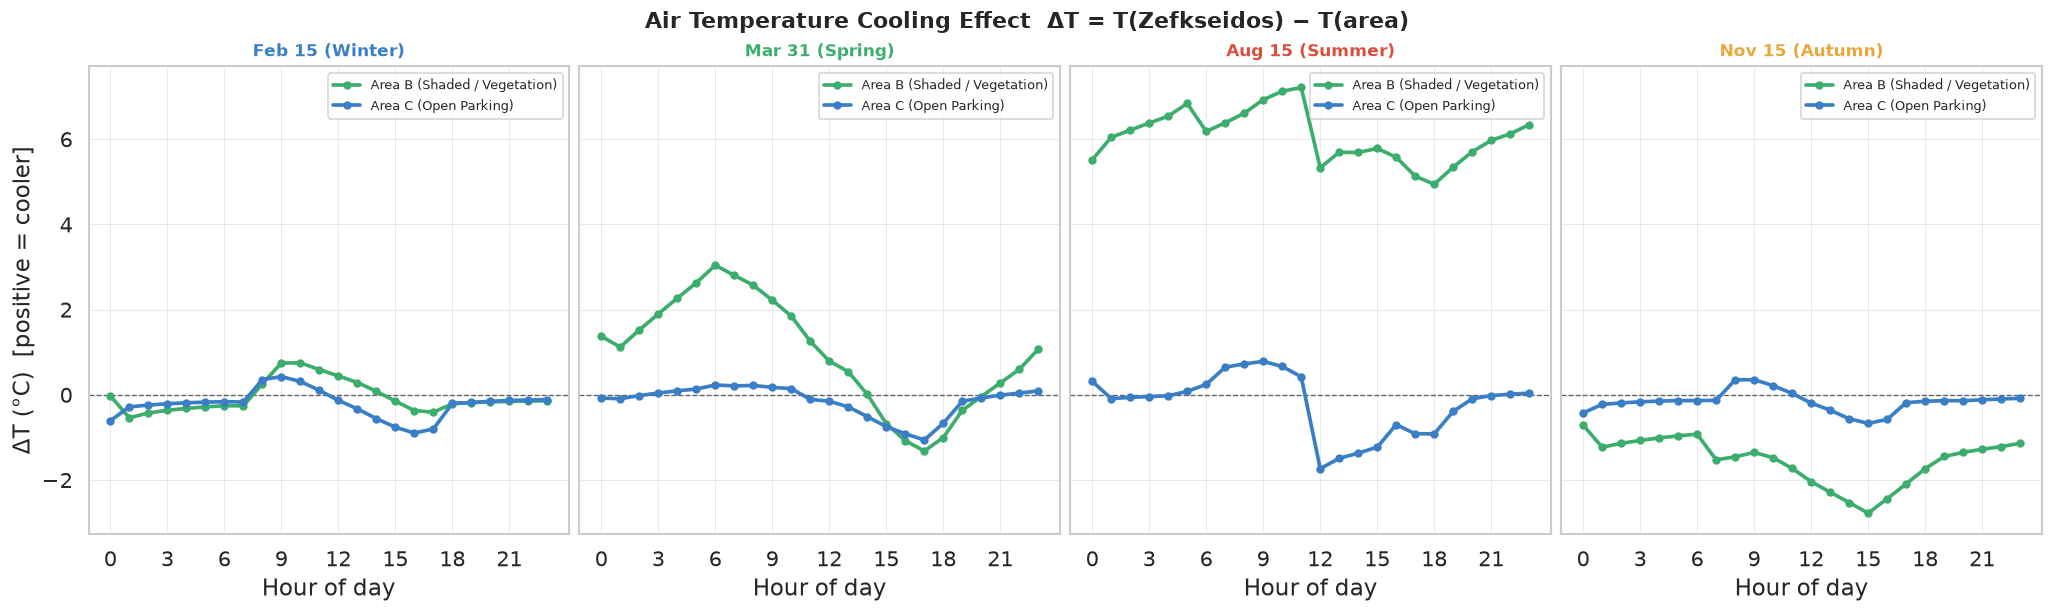

Saved D1


In [4]:
compare_areas = [a for a in AREA_ORDER if a != REFERENCE_AREA]

fig, axes = plt.subplots(1, len(DATE_ORDER), figsize=(17, 5), sharey=True, constrained_layout=True)
fig.suptitle(f'Air Temperature Cooling Effect  ΔT = T({REFERENCE_AREA}) − T(area)',
             fontsize=13, fontweight='bold')

for ax, date in zip(axes, DATE_ORDER):
    ax.set_title(DATE_LABELS[date], fontsize=10, fontweight='bold', color=DATE_COLORS[date])
    ax.set_xlabel('Hour of day')
    if date == DATE_ORDER[0]: ax.set_ylabel('ΔT (°C)  [positive = cooler]')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)

    ref_col = (REFERENCE_AREA, date)
    if ref_col not in atm_piv.columns:
        ax.text(0.5, 0.5, 'No ref data', ha='center', va='center', transform=ax.transAxes)
        continue

    for area in compare_areas:
        col = (area, date)
        if col not in atm_piv.columns: continue
        delta = atm_piv[ref_col] - atm_piv[col]
        hrs = delta.index.tolist()
        ax.plot(hrs, delta.values, color=AREA_COLORS[area], lw=2.2,
                marker='o', ms=4, label=AREA_LABELS[area].replace('\n', ' '))

    ax.set_xticks(range(0, 24, 3))
    ax.grid(lw=0.5, alpha=0.5)
    ax.legend(fontsize=8)

fig.savefig(SAVE_DIR / 'D1_delta_air_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved D1')

## D2 — ΔT surface temperature diurnal curves

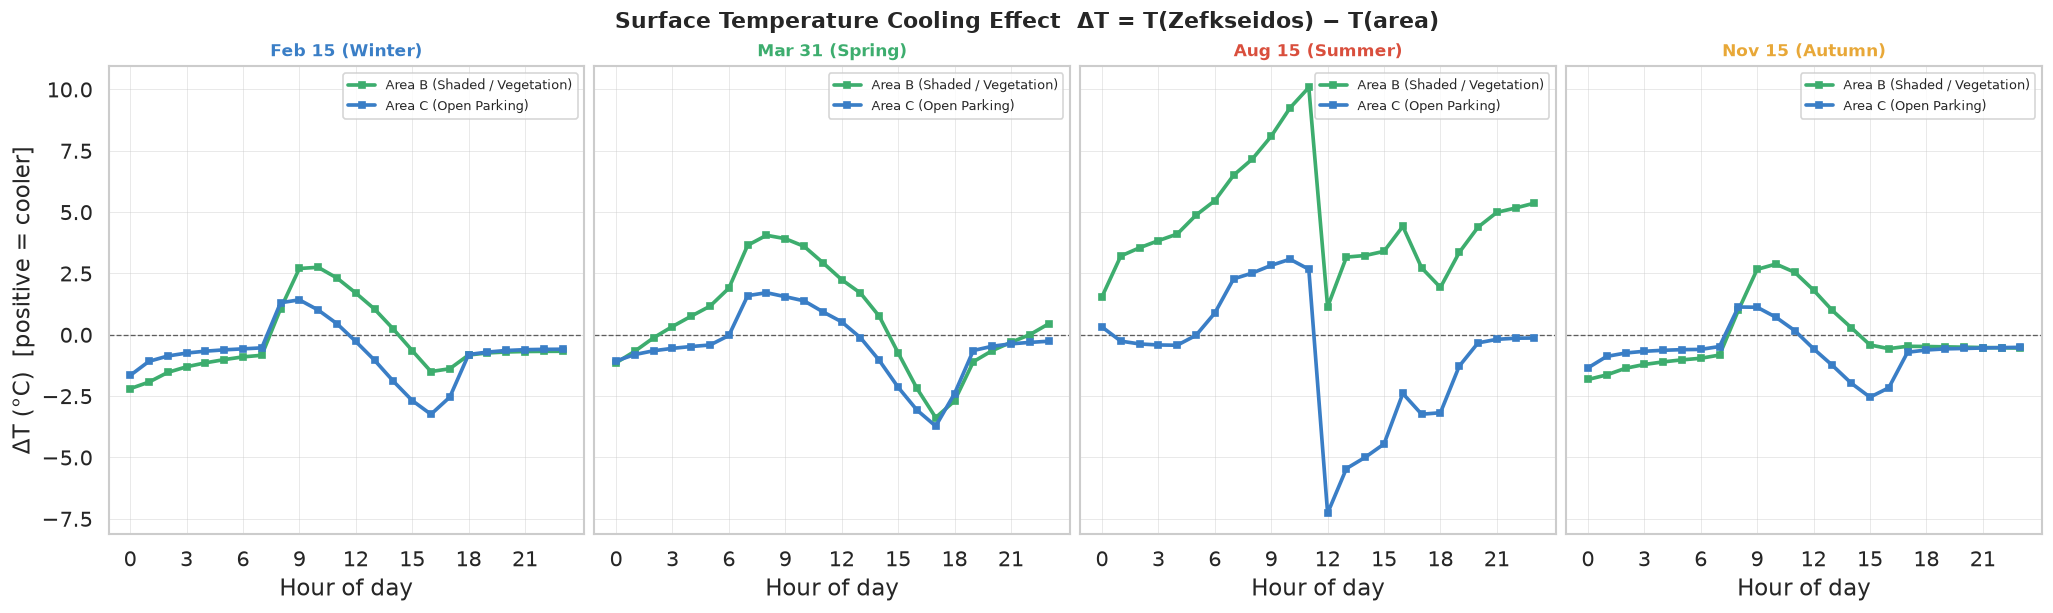

Saved D2


In [5]:
fig, axes = plt.subplots(1, len(DATE_ORDER), figsize=(17, 5), sharey=True, constrained_layout=True)
fig.suptitle(f'Surface Temperature Cooling Effect  ΔT = T({REFERENCE_AREA}) − T(area)',
             fontsize=13, fontweight='bold')

for ax, date in zip(axes, DATE_ORDER):
    ax.set_title(DATE_LABELS[date], fontsize=10, fontweight='bold', color=DATE_COLORS[date])
    ax.set_xlabel('Hour of day')
    if date == DATE_ORDER[0]: ax.set_ylabel('ΔT (°C)  [positive = cooler]')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)

    ref_col = (REFERENCE_AREA, date)
    if ref_col not in srf_piv.columns: continue

    for area in compare_areas:
        col = (area, date)
        if col not in srf_piv.columns: continue
        delta = srf_piv[ref_col] - srf_piv[col]
        ax.plot(delta.index, delta.values, color=AREA_COLORS[area], lw=2.2,
                marker='s', ms=4, label=AREA_LABELS[area].replace('\n', ' '))

    ax.set_xticks(range(0, 24, 3))
    ax.grid(lw=0.5, alpha=0.5)
    ax.legend(fontsize=8)

fig.savefig(SAVE_DIR / 'D2_delta_surface_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved D2')

## D3 — Peak ΔT bar chart (at peak hour 15:00 air / 13:00 surface)

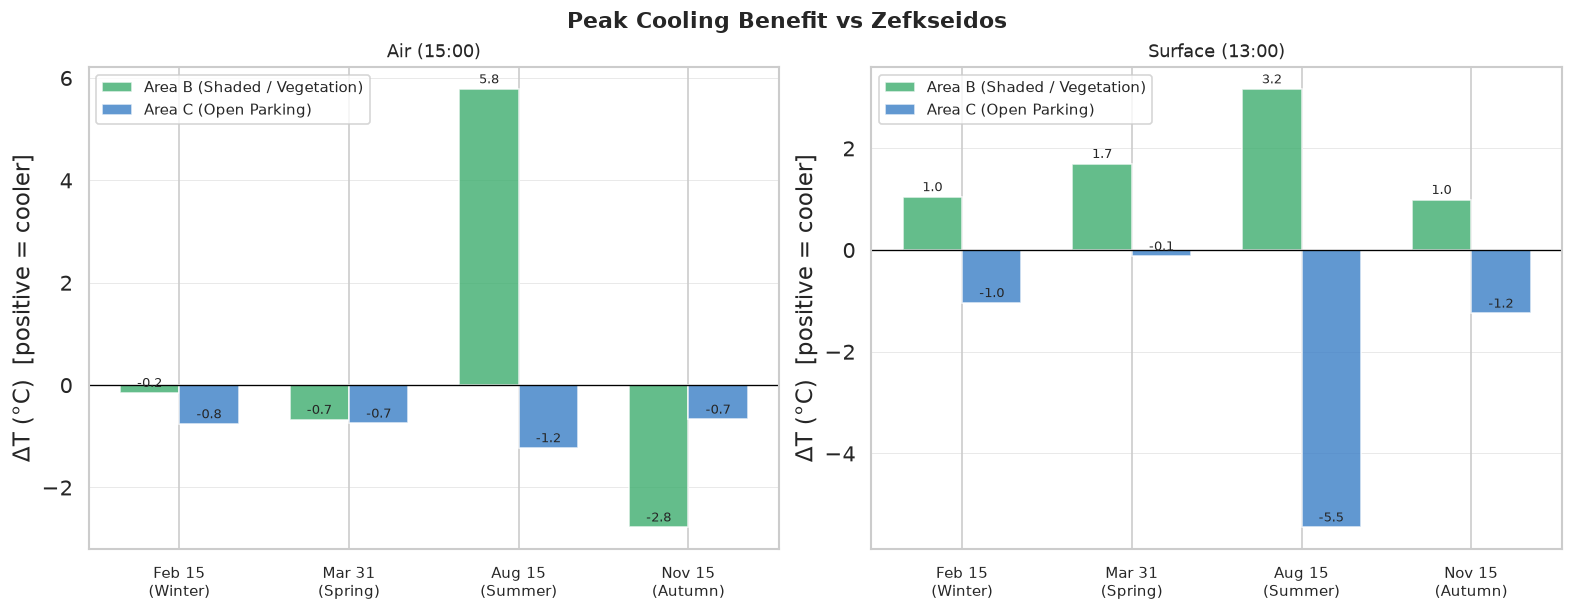

Saved D3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle(f'Peak Cooling Benefit vs {REFERENCE_AREA}', fontsize=13, fontweight='bold')

configs = [('Air (15:00)',  atm_piv, 15), ('Surface (13:00)', srf_piv, 13)]
x_pos = np.arange(len(DATE_ORDER))
width = 0.35

for ax, (title, piv, hour) in zip(axes, configs):
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('ΔT (°C)  [positive = cooler]')
    ax.axhline(0, color='black', lw=0.8)

    for i, area in enumerate(compare_areas):
        deltas = []
        for date in DATE_ORDER:
            try:
                d_ref  = piv.loc[hour, (REFERENCE_AREA, date)]
                d_area = piv.loc[hour, (area, date)]
                deltas.append(d_ref - d_area)
            except (KeyError, TypeError):
                deltas.append(np.nan)
        offset = (i - 0.5) * width
        bars = ax.bar(x_pos + offset, deltas, width, color=AREA_COLORS[area], alpha=0.8,
                      label=AREA_LABELS[area].replace('\n', ' '))
        for bar, val in zip(bars, deltas):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([DATE_LABELS[d].replace(' (', '\n(') for d in DATE_ORDER], fontsize=9)
    ax.grid(axis='y', lw=0.5, alpha=0.5)
    ax.legend(fontsize=9)

fig.savefig(SAVE_DIR / 'D3_peak_delta_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved D3')

## D4 — ΔT summary table

In [7]:
rows = []
for area in compare_areas:
    for date in DATE_ORDER:
        for label, df, col, hour in [('air', atm, AIR_TEMP_COL, 15), ('surface', srf, SURF_TEMP_COL, 13)]:
            ref = df[(df['area'] == REFERENCE_AREA) & (df['date'] == date) & (df['hour'] == hour)][col].mean()
            val = df[(df['area'] == area)           & (df['date'] == date) & (df['hour'] == hour)][col].mean()
            if np.isnan(ref) or np.isnan(val): continue
            rows.append({'vs_area': area, 'Date': date, 'Type': label,
                         'T_ref (°C)': round(ref, 2),
                         'T_area (°C)': round(val, 2),
                         'ΔT (°C)': round(ref - val, 2)})
delta_df = pd.DataFrame(rows)
print(delta_df.to_string(index=False))
print('\nAll done. Figures saved to:', SAVE_DIR)

   vs_area  Date    Type  T_ref (°C)  T_area (°C)  ΔT (°C)
    Shaded 15Feb     air   11.830000    11.980000    -0.15
    Shaded 15Feb surface   15.680000    14.640000     1.04
    Shaded 31Mar     air   18.280001    18.959999    -0.68
    Shaded 31Mar surface   24.680000    22.980000     1.70
    Shaded 15Aug     air   33.400002    27.620001     5.78
    Shaded 15Aug surface   37.169998    34.009998     3.16
    Shaded 15Nov     air   13.460000    16.240000    -2.78
    Shaded 15Nov surface   14.510000    13.520000     0.99
Waterfront 15Feb     air   11.830000    12.590000    -0.76
Waterfront 15Feb surface   15.680000    16.719999    -1.04
Waterfront 31Mar     air   18.280001    19.030001    -0.75
Waterfront 31Mar surface   24.680000    24.799999    -0.12
Waterfront 15Aug     air   33.400002    34.630001    -1.23
Waterfront 15Aug surface   37.169998    42.630001    -5.45
Waterfront 15Nov     air   13.460000    14.140000    -0.67
Waterfront 15Nov surface   14.510000    15.760000    -1.